<a href="https://colab.research.google.com/github/aranzatorres546-hash/M-TODOS-NUM-RICOS-/blob/main/M%C3%89TODO%20DE%20BISECCION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#1f4e79;padding:18px;border-radius:8px">
<h1 style="color:white;margin:0">Método de Bisección</h1>
<h3 style="color:#d6e6f5;margin:4px 0 0 0">Búsqueda de raíces de ecuaciones no lineales</h3>
</div>

**Materia:** Métodos Numéricos  &nbsp;|&nbsp; **Tema:** Solución de ecuaciones de una variable  &nbsp;|&nbsp; **Lenguaje:** Python (NumPy y Matplotlib) &nbsp;|&nbsp; **Nombre del alumno :** Aranza Citlali Rivero Torres

---
**Contenido**
1. Formulación del problema
2. Fundamento teórico
3. Algoritmo
4. Implementación en Python
5. Visualización gráfica
6. Análisis de convergencia y error
7. Solución final

## 1. Formulación del problema

Queremos resolver la ecuación no lineal

$$x^3 + 4x^2 - 10 = 0$$

en el intervalo $[1,2]$. Es decir, buscamos $p\in[1,2]$ tal que $f(p)=0$, donde

$$f(x)=x^3+4x^2-10 .$$

> Una ecuación como esta **no se puede resolver fácilmente de forma algebraica**, por eso se recurre a un método numérico que *aproxime* la raíz con la precisión que se desee.

## 2. Fundamento teórico

###  Teorema del valor intermedio

Si $f$ es **continua** en $[a,b]$ y $f(a)$ y $f(b)$ tienen **signos opuestos**, es decir

$$f(a)\cdot f(b) < 0,$$

entonces existe al menos un número $p\in(a,b)$ tal que $f(p)=0$.

###  Idea del método

Se calcula el **punto medio** del intervalo:

$$p_i = a_i + \frac{b_i-a_i}{2} = \frac{a_i+b_i}{2}$$

y se evalúa $f(p_i)$. Entonces:

| Caso | Conclusión | Nuevo intervalo |
|:---:|:---|:---:|
| $f(a_i)\cdot$ $f(p_i)$ > 0$ | $la raíz está en la mitad derecha | $[a_{i+1},b_{i+1}]=[p_i,\,b_i]$ |
| $f(a_i)\cdot f(p_i) < 0$ | la raíz está en la mitad izquierda | $[a_{i+1},b_{i+1}]=[a_i,\,p_i]$ |
| $f(p_i) = 0$ | $p_i$ es la raíz exacta | — |

En cada iteración **la longitud del intervalo se reduce a la mitad**.

### 2.3 Error y criterio de paro

El error en la iteración $i$ se toma como la longitud del intervalo:

$$\text{error}_i = |b_i - a_i|$$

El método se detiene cuando $\text{error}_i < \text{tol}$ o cuando se alcanza el número máximo de iteraciones `nmax`.

### 2.4 Número de iteraciones necesarias

Como el intervalo se reduce a la mitad en cada paso, después de $n$ iteraciones su longitud es $\dfrac{b-a}{2^n}$. Para lograr una tolerancia $\text{tol}$:

$$\frac{b-a}{2^n} < \text{tol} \quad\Longrightarrow\quad n > \log_2\!\left(\frac{b-a}{\text{tol}}\right)$$

## 3. Algoritmo

<div style="background-color:#f2f2f2;padding:12px;border-left:6px solid #1f4e79">

**Entrada:** función $f$, extremos $a,b$, tolerancia `tol`, máximo de iteraciones `nmax`.

1. Verificar que $f(a)\cdot f(b)<0$. Si no, detenerse: el método no aplica.
2. Calcular $p = a + \frac{b-a}{2}$.
3. Si $f(p)=0$ o $|b-a|<\text{tol}$, **terminar** y devolver $p$.
4. Si $f(a)\cdot f(p)>0$, hacer $a=p$; en otro caso, hacer $b=p$.
5. Repetir desde el paso 2 (hasta `nmax` veces).

**Salida:** aproximación de la raíz $p$.
</div>

## 4. Implementación en Python

### 4.1 Librerías

- `numpy` (se importa como `np`): funciones matemáticas y arreglos.
- `matplotlib.pyplot` (se importa como `plt`): gráficas.

> **Sintaxis:** una función de una biblioteca se llama así: `biblioteca.modulo.funcion()`, por ejemplo `np.linspace(...)` o `plt.plot(...)`.

In [1]:
import numpy as np                # funciones matemáticas y arreglos
import matplotlib.pyplot as plt   # gráficas

### 4.2 Definición de la función

> **Sintaxis:** `def` define una función; `return` devuelve su resultado. En Python la potencia se escribe con `**` (no con `^`), y el producto con `*`.

In [3]:
def f(x):
    return x**3 + 4*x**2 - 10     # f(x) = x^3 + 4x^2 - 10

### 4.3 Verificación de la hipótesis del método

Comprobamos que hay cambio de signo en $[1,2]$.

In [4]:
print("f(1) =", f(1))
print("f(2) =", f(2))
print("f(1)*f(2) =", f(1)*f(2), " -> menor que 0, el método de bisección aplica")

f(1) = -5
f(2) = 14
f(1)*f(2) = -70  -> menor que 0, el método de bisección aplica


Como $f(1)=-5<0$ y $f(2)=14>0$, por el teorema del valor intermedio **existe una raíz en $[1,2]$**.

### 4.4 Hiperparámetros

Son los datos de entrada del método: el intervalo, la tolerancia y el máximo de iteraciones.

> **Sintaxis:** `1e-6` es notación científica y equivale a $10^{-6}=0.000001$. El símbolo `#` inicia un comentario.

In [6]:
# Datos de entrada
a = 1
b = 2

# Guardamos los valores iniciales (a y b cambiarán durante las iteraciones)
a0 = a
b0 = b

# Parámetros del método
tol  = 1e-6      # tolerancia: el método para cuando |b - a| < tol
nmax = 100       # número máximo de iteraciones
error = 100      # valor inicial grande para que el ciclo arranque
niter = 0        # contador de iteraciones

# Número de iteraciones esperado según la teoría: n > log2((b-a)/tol)
print("Iteraciones esperadas: n >", np.log2((b - a)/tol))

Iteraciones esperadas: n > 19.931568569324174


### 4.5 Método de bisección (todas las iteraciones)

> **Sintaxis utilizada**
> - `while condición:` repite el bloque mientras la condición sea verdadera.
> - `if / else` ejecuta un bloque u otro según se cumpla la condición.
> - `np.sign(x)` devuelve $-1$, $0$ o $+1$ según el signo de `x`; sirve para comparar signos sin multiplicar.
> - `a, fa = m, fm` asigna dos variables a la vez.
> - `f"{x:.6f}"` es una *f-string*: muestra `x` con 6 decimales. `\t` inserta un tabulador.
> - Guardamos cada iteración en la lista `tabla` con `append` para poder graficarla después.

In [7]:
fa, fb = f(a), f(b)
assert fa * fb < 0, "No hay cambio de signo en [a,b]: el método no aplica"

m  = a + (b - a)/2          # primer punto medio
fm = f(m)

tabla = []                  # aquí guardamos cada iteración

print("iter\t a\t\t f(a)\t\t b\t\t f(b)\t\t m\t\t f(m)\t\t error")
print(f"{niter}\t {a:.6f}\t {fa:.6f}\t {b:.6f}\t {fb:.6f}\t {m:.6f}\t {fm:.6f}\t {error:.6f}")
tabla.append((niter, a, b, m, fm, error))

while error > tol and niter < nmax and fm != 0:
    if np.sign(fa) == np.sign(fm):     # la raíz está en [m, b]
        a, fa = m, fm
    else:                              # la raíz está en [a, m]
        b, fb = m, fm
    m  = a + (b - a)/2                 # nuevo punto medio
    fm = f(m)
    error = abs(b - a)                 # longitud del intervalo
    niter += 1
    print(f"{niter}\t {a:.6f}\t {fa:.6f}\t {b:.6f}\t {fb:.6f}\t {m:.6f}\t {fm:.6f}\t {error:.6f}")
    tabla.append((niter, a, b, m, fm, error))

print(f"\nLa raíz de la función en el intervalo [{a0:.4f}, {b0:.4f}] es {m:.7f}")
print(f"Iteraciones realizadas: {niter}")

iter	 a		 f(a)		 b		 f(b)		 m		 f(m)		 error
0	 1.000000	 -5.000000	 2.000000	 14.000000	 1.500000	 2.375000	 100.000000
1	 1.000000	 -5.000000	 1.500000	 2.375000	 1.250000	 -1.796875	 0.500000
2	 1.250000	 -1.796875	 1.500000	 2.375000	 1.375000	 0.162109	 0.250000
3	 1.250000	 -1.796875	 1.375000	 0.162109	 1.312500	 -0.848389	 0.125000
4	 1.312500	 -0.848389	 1.375000	 0.162109	 1.343750	 -0.350983	 0.062500
5	 1.343750	 -0.350983	 1.375000	 0.162109	 1.359375	 -0.096409	 0.031250
6	 1.359375	 -0.096409	 1.375000	 0.162109	 1.367188	 0.032356	 0.015625
7	 1.359375	 -0.096409	 1.367188	 0.032356	 1.363281	 -0.032150	 0.007812
8	 1.363281	 -0.032150	 1.367188	 0.032356	 1.365234	 0.000072	 0.003906
9	 1.363281	 -0.032150	 1.365234	 0.000072	 1.364258	 -0.016047	 0.001953
10	 1.364258	 -0.016047	 1.365234	 0.000072	 1.364746	 -0.007989	 0.000977
11	 1.364746	 -0.007989	 1.365234	 0.000072	 1.364990	 -0.003959	 0.000488
12	 1.364990	 -0.003959	 1.365234	 0.000072	 1.365112	 -0.001944	 

## 5. Visualización gráfica

### 5.1 La función y la raíz

La raíz es el punto donde la curva cruza el eje $x$. Las líneas punteadas marcan el intervalo inicial $[1,2]$.

> **Sintaxis:** `np.linspace(0, 3, 200)` genera 200 puntos igualmente espaciados entre 0 y 3. Al evaluar `f(x)` sobre un arreglo, NumPy calcula `f` en todos los puntos a la vez.

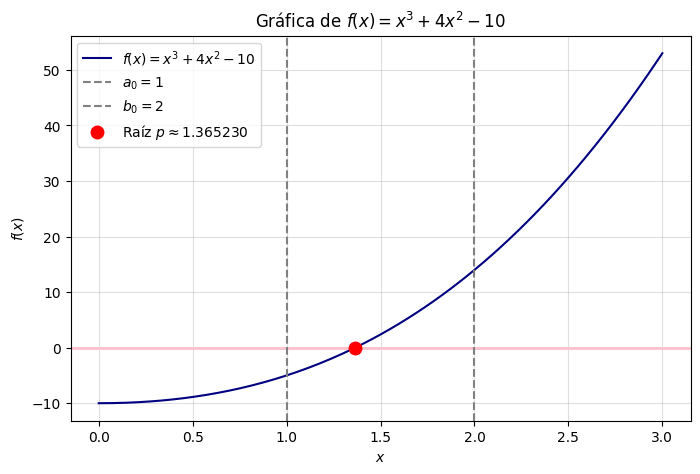

In [8]:
x = np.linspace(0, 3, 200)
plt.figure(figsize=(8, 5))
plt.plot(x, f(x), color='navy', label='$f(x)=x^3+4x^2-10$')
plt.axhline(y=0, color='pink', linewidth=2)                       # eje y = 0
plt.axvline(x=a0, color='gray', linestyle='--', label='$a_0=1$')  # extremo izquierdo
plt.axvline(x=b0, color='gray', linestyle='--', label='$b_0=2$')  # extremo derecho
plt.plot(m, f(m), 'ro', markersize=9, label=f'Raíz $p \\approx {m:.6f}$')
plt.title("Gráfica de $f(x)=x^3+4x^2-10$")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

### 5.2 Cómo se reduce el intervalo

Cada línea horizontal es el intervalo $[a_i,b_i]$ de una iteración y el punto rojo es su punto medio $p_i$. Se ve cómo el intervalo se encierra alrededor de la raíz.

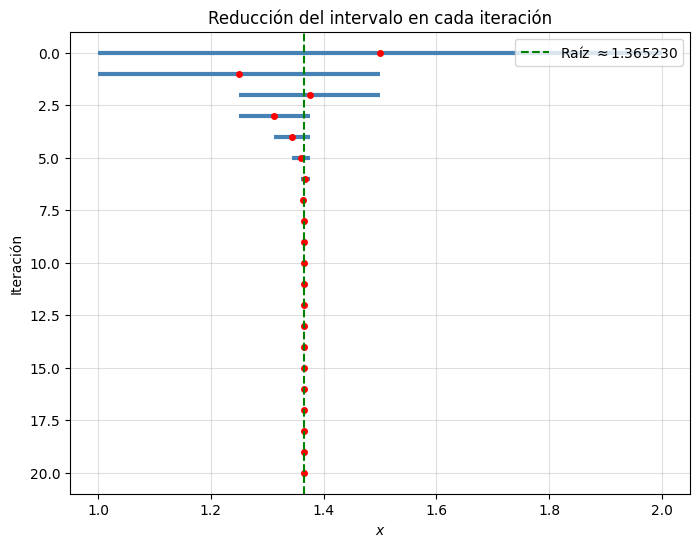

In [ ]:
plt.figure(figsize=(8, 6))
for it, ai, bi, mi, fmi, ei in tabla:
    plt.hlines(y=it, xmin=ai, xmax=bi, color='steelblue', linewidth=3)
    plt.plot(mi, it, 'ro', markersize=4)
plt.axvline(m, color='green', linestyle='--', label=f'Raíz $\\approx {m:.6f}$')
plt.gca().invert_yaxis()            # la iteración 0 arriba
plt.title("Reducción del intervalo en cada iteración")
plt.xlabel("$x$")
plt.ylabel("Iteración")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

## 6. Análisis de convergencia y error

El error se reduce **a la mitad** en cada iteración: $\text{error}_i = \dfrac{b_0-a_0}{2^i}$. En escala logarítmica esto es una línea recta. La línea roja es la tolerancia.

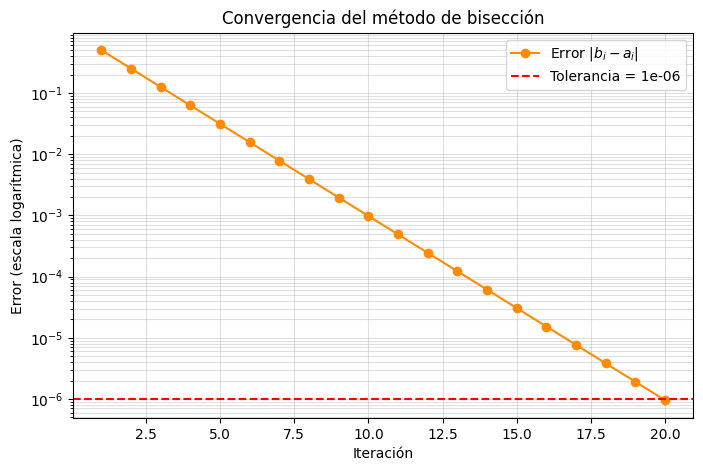

In [ ]:
iteraciones = [t[0] for t in tabla[1:]]    # se omite la iteración 0 (error inicial = 100, es solo un valor de arranque)
errores     = [t[5] for t in tabla[1:]]

plt.figure(figsize=(8, 5))
plt.semilogy(iteraciones, errores, 'o-', color='darkorange', label='Error $|b_i-a_i|$')
plt.axhline(tol, color='red', linestyle='--', label=f'Tolerancia = {tol:g}')
plt.title("Convergencia del método de bisección")
plt.xlabel("Iteración")
plt.ylabel("Error (escala logarítmica)")
plt.grid(alpha=0.4, which='both')
plt.legend()
plt.show()

## 7. Solución final

Verificamos el resultado evaluando $f$ en la raíz aproximada:

In [ ]:
print(f"Raíz aproximada  p    = {m:.7f}")
print(f"f(p)                  = {f(m):.2e}   (muy cercano a 0)")
print(f"Cota del error       <= {abs(b - a):.2e}  (menor que tol = {tol:g})")

Raíz aproximada  p    = 1.3652301
f(p)                  = 1.16e-06   (muy cercano a 0)
Cota del error       <= 9.54e-07  (menor que tol = 1e-06)


<div style="background-color:#e2f0d9;border:3px solid #2e7d32;padding:16px;border-radius:8px">
<h3 style="color:#1b5e20;margin-top:0">✔ Solución final</h3>

La ecuación $x^3+4x^2-10=0$ tiene una raíz en el intervalo $[1,2]$ dada por

$$\boxed{\,p \approx 1.3652300\,}$$

obtenida con el método de bisección en **20 iteraciones**, con tolerancia $10^{-6}$ y $f(p)\approx 10^{-6}$.
</div>

### Conclusiones

- El método **siempre converge** si $f$ es continua y hay cambio de signo en $[a,b]$.
- Su convergencia es **lenta pero segura**: el error se reduce a la mitad en cada iteración (convergencia lineal).
- El número de iteraciones se puede conocer **antes** de ejecutar: $n>\log_2\!\left(\frac{b-a}{\text{tol}}\right)\approx 19.93$, es decir, $n=20$, lo que coincide con lo obtenido.